**DATA PREPROCESSING** 

In [1]:
import pandas as pd
import re
import unicodedata


In [2]:
def load_and_fix_csv(path):
    # Explicitly read TAB-separated file
    df = pd.read_csv(path, sep="\t", header=None)

    # Keep only text and label columns
    df = df.iloc[:, :2]
    df.columns = ["text", "label"]

    # Drop empty rows
    df.dropna(subset=["text", "label"], inplace=True)

    # Strip whitespace
    df["text"] = df["text"].astype(str).str.strip()
    df["label"] = df["label"].astype(str).str.strip()

    return df


In [16]:
def normalize_labels(df):
    # Convert to string, strip spaces, normalize case
    df["label"] = (
        df["label"]
        .astype(str)
        .str.strip()
        .str.replace(r"\s+", "", regex=True)  # remove hidden spaces/tabs
    )

    # Not_offensive -> 0
    # Everything else -> 1
    df["label"] = df["label"].apply(
        lambda x: 0 if "Not_offensive" in x else 1
    )

    return df



def normalize_unicode(text):
    return unicodedata.normalize("NFC", text)

def normalize_repeats(text):
    return re.sub(r"(.)\1{2,}", r"\1\1", text)

def normalize_special_tokens(text):
    text = re.sub(r"http\S+|www\S+", "<URL>", text)
    text = re.sub(r"@\w+", "<USER>", text)
    text = re.sub(r"\d+", "<NUM>", text)
    return text

def preprocess_text(text):
    text = normalize_unicode(text)
    text = normalize_repeats(text)
    text = normalize_special_tokens(text)
    return text.strip()

def add_language_tag(df, lang_tag):
    df["text"] = f"<{lang_tag}> " + df["text"]
    return df


In [17]:
def preprocess_dataset(path, lang_tag):
    df = load_and_fix_csv(path)
    df = normalize_labels(df)
    df["text"] = df["text"].apply(preprocess_text)
    df = add_language_tag(df, lang_tag)
    return df


In [18]:
# Malayalam
mal_train = preprocess_dataset("/kaggle/input/dataset/mal_full_offensive_train.csv", "ml")
mal_dev   = preprocess_dataset("/kaggle/input/dataset/mal_full_offensive_dev.csv", "ml")
mal_test  = preprocess_dataset("/kaggle/input/dataset/mal_full_offensive_test.csv", "ml")

# Tamil
tam_train = preprocess_dataset("/kaggle/input/dataset/tamil_offensive_full_train.csv", "ta")
tam_dev   = preprocess_dataset("/kaggle/input/dataset/tamil_offensive_full_dev.csv", "ta")
tam_test  = preprocess_dataset("/kaggle/input/dataset/tamil_offensive_full_test.csv", "ta")


In [19]:
print(mal_train.head())
print(mal_train.columns)
print(mal_train["label"].value_counts())

                                                text  label
0  <ml> പലദേശം. പല ഭാഷ ഒരേ ഒരു രാജാവ്  അല്ലാതെ  സ...      0
1  <ml> ഈ ഓണം ഏട്ടനും പിള്ളേർക്ക് ഉള്ളതാണ് എന്ന് ...      0
2  <ml> ആരണ്ട ആരണ്ട തലുണ്ടാകാണാ ആരണ്ട ഞാൻ ആണ്ട ഞാ...      0
3     <ml> Sushin syam  Shaiju khalid  Midhun manual      0
4                       <ml> J A K E S.  B EJ O Y !!      0
Index(['text', 'label'], dtype='object')
label
0    14153
1     1857
Name: count, dtype: int64


In [20]:
print(tam_train.head())
print(tam_train.columns)
print(tam_train["label"].value_counts())

                                                text  label
0             <ta> movie vara level la Erika poguthu      0
1  <ta> I love Ajith Kumar Vivegam movie inki mjy...      1
2     <ta> Padam nalla comedy padama irukum polaye..      0
3  <ta> karthick subburaj anne .. intha padam vet...      0
4  <ta> கவுண்டர் தேவர்.சார்பாக வெற்றி பெற வாழ்த்த...      0
Index(['text', 'label'], dtype='object')
label
0    25425
1     9714
Name: count, dtype: int64


In [21]:
# Combine TRAIN
train_df = pd.concat([mal_train, tam_train], ignore_index=True)

# Combine DEV
validation_df = pd.concat([mal_dev, tam_dev], ignore_index=True)

# Combine TEST
test_df = pd.concat([mal_test, tam_test], ignore_index=True)


In [22]:
print(train_df.shape, validation_df.shape, test_df.shape)
print(train_df["label"].value_counts())


(51149, 2) (6387, 2) (6393, 2)
label
0    39578
1    11571
Name: count, dtype: int64


In [23]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

labels = train_df["label"].values

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=labels
)

class_weights = {
    0: class_weights[0],
    1: class_weights[1]
}

print(class_weights)


{0: np.float64(0.6461796957905908), 1: np.float64(2.210223835450696)}


In [24]:
print(train_df["label"].value_counts())
print(train_df["label"].value_counts(normalize=True))


label
0    39578
1    11571
Name: count, dtype: int64
label
0    0.773779
1    0.226221
Name: proportion, dtype: float64


****MuRIL MODEL FINE TUNING PART****

In [25]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel
from torch.optim import AdamW
from sklearn.metrics import classification_report, confusion_matrix


In [26]:
tokenizer = AutoTokenizer.from_pretrained(
    "google/muril-base-cased"
)


tokenizer_config.json:   0%|          | 0.00/206 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/411 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/113 [00:00<?, ?B/s]

In [27]:
class OffensiveDataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts = df["text"].values
        self.labels = df["label"].values
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            padding="max_length",
            truncation=True,
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(self.labels[idx], dtype=torch.float)
        }


In [28]:
BATCH_SIZE = 16

train_dataset = OffensiveDataset(train_df, tokenizer)
validation_dataset   = OffensiveDataset(validation_df, tokenizer)
test_dataset  = OffensiveDataset(test_df, tokenizer)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
validation_loader   = DataLoader(validation_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)


In [29]:
class MurilClassifier(nn.Module):
    def __init__(self):
        super().__init__()
        self.muril = AutoModel.from_pretrained("google/muril-base-cased")
        self.fc1 = nn.Linear(768, 256)
        self.dropout = nn.Dropout(0.3)
        self.fc2 = nn.Linear(256, 1)
        self.relu = nn.ReLU()
        self.sigmoid = nn.Sigmoid()

    def forward(self, input_ids, attention_mask):
        outputs = self.muril(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.last_hidden_state[:, 0, :]  # [CLS]
        x = self.relu(self.fc1(cls_output))
        x = self.dropout(x)
        x = self.sigmoid(self.fc2(x))
        return x


In [30]:
model = MurilClassifier()

for name, param in model.muril.named_parameters():
    if "encoder.layer.9" in name or \
       "encoder.layer.10" in name or \
       "encoder.layer.11" in name:
        param.requires_grad = True
    else:
        param.requires_grad = False


2026-01-21 06:43:15.450000: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1768977795.632850      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1768977795.688225      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1768977796.143596      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768977796.143637      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1768977796.143640      55 computation_placer.cc:177] computation placer alr

pytorch_model.bin:   0%|          | 0.00/953M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/953M [00:00<?, ?B/s]

In [31]:
pos_weight = torch.tensor([2.0])  # offensive boost

criterion = nn.BCELoss(weight=None)


In [32]:
optimizer = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=2e-5
)


In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)


MurilClassifier(
  (muril): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(197285, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (token_type_embeddings): Embedding(2, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-11): 12 x BertLayer(
          (attention): BertAttention(
            (self): BertSdpaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (LayerNorm): LayerNorm((768,), eps=1e-12, element

In [34]:
def binary_accuracy(preds, labels):
    preds = (preds >= 0.5).float()
    correct = (preds == labels).float()
    return correct.mean()


In [35]:
def evaluate_loss_and_accuracy(model, loader):
    model.eval()
    total_loss = 0
    total_acc = 0

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask).squeeze()
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            total_acc += binary_accuracy(outputs, labels).item()

    avg_loss = total_loss / len(loader)
    avg_acc = total_acc / len(loader)

    return avg_loss, avg_acc


In [36]:
train_losses, train_accuracies = [], []
validation_losses, validation_accuracies = [], []

EPOCHS = 3
best_validation_loss = float("inf")

for epoch in range(EPOCHS):

    # ===== TRAINING =====
    model.train()
    total_train_loss = 0
    total_train_acc = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask).squeeze()
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        total_train_acc += binary_accuracy(outputs, labels).item()

    avg_train_loss = total_train_loss / len(train_loader)
    avg_train_acc = total_train_acc / len(train_loader)

    # ===== VALIDATION =====
    avg_validation_loss, avg_validation_acc = evaluate_loss_and_accuracy(
        model, validation_loader   
    )

    train_losses.append(avg_train_loss)
    train_accuracies.append(avg_train_acc)
    validation_losses.append(avg_validation_loss)
    validation_accuracies.append(avg_validation_acc)

    print(f"\nEpoch {epoch+1}")
    print(f"Train Loss: {avg_train_loss:.4f} | Train Acc: {avg_train_acc:.4f}")
    print(f"Validation Loss: {avg_validation_loss:.4f} | Validation Acc: {avg_validation_acc:.4f}")

    # ===== SAVE BEST MODEL =====
    if avg_validation_loss < best_validation_loss:
        best_validation_loss = avg_validation_loss
        torch.save(model.state_dict(), "best_muril_model.pt")



Epoch 1
Train Loss: 0.4591 | Train Acc: 0.8010
Validation Loss: 0.3602 | Validation Acc: 0.8305

Epoch 2
Train Loss: 0.3530 | Train Acc: 0.8412
Validation Loss: 0.3232 | Validation Acc: 0.8561

Epoch 3
Train Loss: 0.3234 | Train Acc: 0.8560
Validation Loss: 0.3133 | Validation Acc: 0.8591


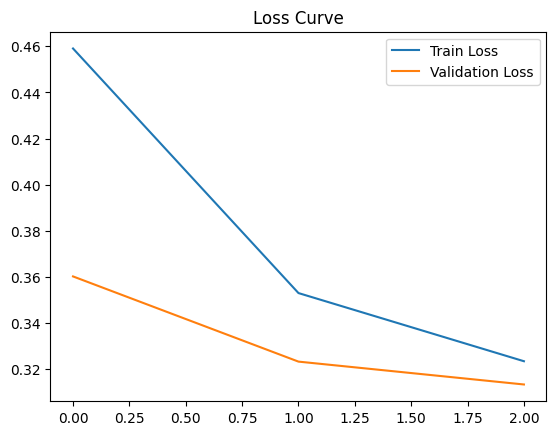

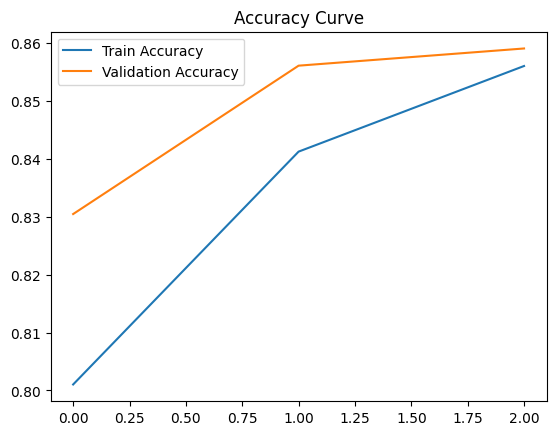

In [38]:
import matplotlib.pyplot as plt

plt.plot(train_losses, label="Train Loss")
plt.plot(validation_losses, label="Validation Loss")
plt.legend()
plt.title("Loss Curve")
plt.show()

plt.plot(train_accuracies, label="Train Accuracy")
plt.plot(validation_accuracies, label="Validation Accuracy")
plt.legend()
plt.title("Accuracy Curve")
plt.show()


In [39]:
def evaluate_accuracy(model, loader):
    model.eval()
    total_acc = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask).squeeze()
            acc = binary_accuracy(outputs, labels)

            total_acc += acc.item()

            all_preds.extend((outputs >= 0.5).int().cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return total_acc / len(loader), all_preds, all_labels


In [40]:
test_acc, test_preds, test_labels = evaluate_accuracy(model, test_loader)

print(f"Test Accuracy: {test_acc:.4f}")


Test Accuracy: 0.8588


In [41]:
from sklearn.metrics import classification_report

print(classification_report(
    test_labels,
    test_preds,
    target_names=["Not-Offensive", "Offensive"]
))


               precision    recall  f1-score   support

Not-Offensive       0.88      0.95      0.91      4955
    Offensive       0.77      0.53      0.63      1438

     accuracy                           0.86      6393
    macro avg       0.82      0.74      0.77      6393
 weighted avg       0.85      0.86      0.85      6393



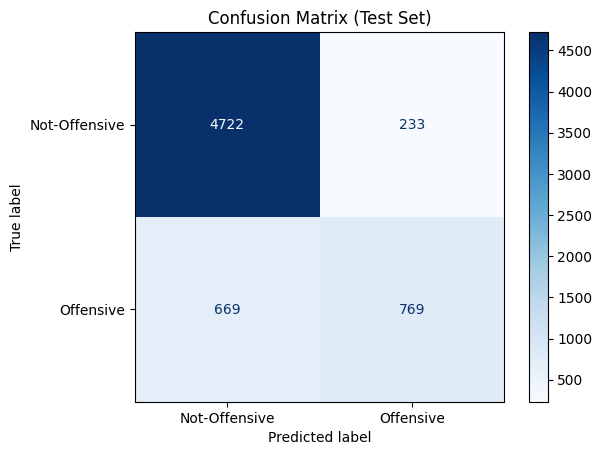

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(test_labels, test_preds)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not-Offensive", "Offensive"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix (Test Set)")
plt.show()
